# **1.0 General Setup**

### 1.1 Mount Google Drive & Set Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, os
%cd /content/drive/MyDrive/AlternativeAssessment_WOA7015/Med-VQA-CNN-LSTM-BLIP/src
sys.path.append(os.getcwd())

[Errno 2] No such file or directory: '/content/drive/MyDrive/AlternativeAssessment_WOA7015/Med-VQA-CNN-LSTM-BLIP/src'
/content


In [ ]:
!ls

drive  sample_data


### 1.2 Dataset paths

In [ ]:
DATASET_DIR = "/content/drive/MyDrive/AlternativeAssessment_WOA7015/Dataset"
EXCEL_PATH = "/content/drive/MyDrive/AlternativeAssessment_WOA7015/Dataset/VQA_RAD Dataset Public.xlsx"
IMAGE_DIR  = "/content/drive/MyDrive/AlternativeAssessment_WOA7015/Dataset/VQA_RAD Image Folder"

### 1.3 Install Required Packages

In [ ]:
!pip install torch torchvision transformers accelerate pillow pandas openpyxl tqdm --quiet

### 1.4 Imports

In [ ]:
import sys, os, random, re
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import BlipProcessor, BlipForQuestionAnswering

torch.manual_seed(42)
random.seed(42)

# **2.0 CNN+LSTM Baseline Model**

### 2.1 Load Dataset

In [ ]:
df_cnn = pd.read_excel(EXCEL_PATH)
df_cnn['image_name'] = df_cnn['IMAGEID'].apply(lambda x: os.path.basename(str(x)))
df_cnn['image_path'] = df_cnn['image_name'].apply(lambda x: os.path.join(IMAGE_DIR, x))
df_cnn = df_cnn[['image_path','QUESTION','ANSWER']]
df_cnn = df_cnn[df_cnn['image_path'].apply(os.path.exists)].reset_index(drop=True)
df_cnn['ANSWER'] = df_cnn['ANSWER'].str.lower().str.strip()

print("CNN+LSTM Samples:", len(df_cnn))

CNN+LSTM Samples: 2248


### 2.2 Question Encoding

In [ ]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", "", text)
    return text.split()

counter = Counter()
for q in df_cnn['QUESTION']:
    counter.update(tokenize(q))

vocab = {word: idx+1 for idx, (word, _) in enumerate(counter.items())}
vocab['<PAD>'] = 0
vocab_size = len(vocab)

MAX_LEN = 20
def encode_question(question):
    tokens = tokenize(question)
    encoded = [vocab.get(tok, 0) for tok in tokens]
    if len(encoded) < MAX_LEN:
        encoded += [0]*(MAX_LEN - len(encoded))
    else:
        encoded = encoded[:MAX_LEN]
    return encoded

df_cnn['question_encoded'] = df_cnn['QUESTION'].apply(encode_question)

### 2.3 Encode Answers

In [ ]:
answers = df_cnn['ANSWER'].unique()
answer2idx = {ans: idx for idx, ans in enumerate(answers)}
idx2answer = {idx: ans for ans, idx in answer2idx.items()}

df_cnn['answer_encoded'] = df_cnn['ANSWER'].map(answer2idx)
num_answers = len(answer2idx)

print("Number of CNN+LSTM answers:", num_answers)

Number of CNN+LSTM answers: 513


### 2.4 PyTorch Dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

class VQADataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = transform(Image.open(row['image_path']).convert("RGB"))
        question = torch.tensor(row['question_encoded'], dtype=torch.long)
        answer = torch.tensor(row['answer_encoded'], dtype=torch.long)
        return image, question, answer

### 2.5 Train/Validation Split

In [ ]:
train_df_cnn, val_df_cnn = train_test_split(df_cnn, test_size=0.2, random_state=42)
train_dataset_cnn = VQADataset(train_df_cnn)
val_dataset_cnn   = VQADataset(val_df_cnn)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=4, shuffle=True)
val_loader_cnn   = DataLoader(val_dataset_cnn, batch_size=4, shuffle=False)

split_df = pd.DataFrame({
    "Model": ["CNN+LSTM"],
    "Train Samples": [len(train_dataset_cnn)],
    "Validation Samples": [len(val_dataset_cnn)]
})
display(split_df)

,Model,Train Samples,Validation Samples
0,CNN+LSTM,1798,450


### 2.6 Model Definition

In [ ]:
class CNN_LSTM_VQA(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_answers):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(2048 + hidden_dim, num_answers)
    def forward(self, images, questions):
        img_features = self.cnn(images).view(images.size(0), -1)
        q_embed = self.embedding(questions)
        _, (hidden, _) = self.lstm(q_embed)
        q_features = hidden[-1]
        combined = torch.cat((img_features, q_features), dim=1)
        return self.fc(combined)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = CNN_LSTM_VQA(vocab_size, embed_dim=128, hidden_dim=256, num_answers=num_answers).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 93.2MB/s]


### 2.7 Training Loop

In [ ]:
num_epochs = 5
train_losses_cnn = []

for epoch in range(num_epochs):
    model_cnn.train()
    total_loss = 0
    for images, questions, labels in train_loader_cnn:
        images, questions, labels = images.to(device), questions.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_cnn(images, questions)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss/len(train_loader_cnn)
    train_losses_cnn.append(avg_loss)
    print(f"CNN+LSTM Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

CNN+LSTM Epoch 1/5 | Loss: 4.2745
CNN+LSTM Epoch 2/5 | Loss: 3.8501
CNN+LSTM Epoch 3/5 | Loss: 3.8103
CNN+LSTM Epoch 4/5 | Loss: 3.6549
CNN+LSTM Epoch 5/5 | Loss: 3.1975


### 2.8 Validation Loop

In [ ]:
model_cnn.eval()
val_losses_cnn = []
total_correct = 0
with torch.no_grad():
    for images, questions, labels in val_loader_cnn:
        images, questions, labels = images.to(device), questions.to(device), labels.to(device)
        outputs = model_cnn(images, questions)
        loss = criterion(outputs, labels)
        val_losses_cnn.append(loss.item())
        preds = outputs.argmax(dim=1)
        total_correct += (preds==labels).sum().item()

val_acc_cnn = total_correct / len(val_dataset_cnn)
print(f"CNN+LSTM Validation Accuracy: {val_acc_cnn:.4f}")

CNN+LSTM Validation Accuracy: 0.3444


### 2.9 Plot Loss

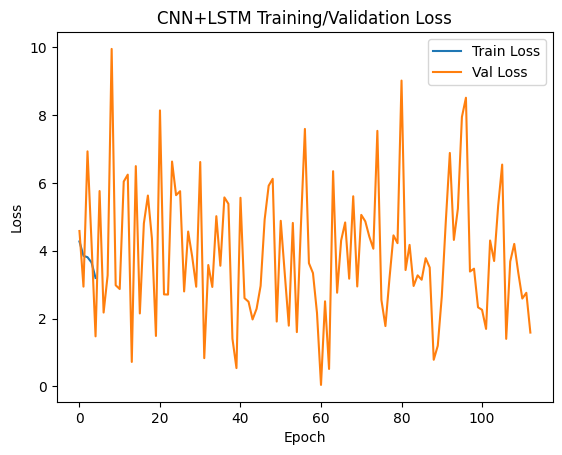

In [ ]:
plt.plot(train_losses_cnn, label='Train Loss')
plt.plot(val_losses_cnn, label='Val Loss')
plt.title("CNN+LSTM Training/Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 2.10 Sample inference table

In [ ]:
sample_cnn = val_df_cnn.sample(10, random_state=42)
results_cnn = []

model_cnn.eval()
with torch.no_grad():
    for _, row in sample_cnn.iterrows():
        img = transform(Image.open(row['image_path']).convert("RGB")).unsqueeze(0).to(device)
        question = torch.tensor([row['question_encoded']], dtype=torch.long).to(device)

        gt = row['ANSWER'].lower().strip()
        outputs = model_cnn(img, question)
        pred_idx = outputs.argmax(dim=1).item()
        pred = idx2answer[pred_idx].lower().strip()

        match = pred == gt
        comment = "Correct" if match else "Wrong Class"

        results_cnn.append({
            "Question": row['QUESTION'],
            "Ground Truth": gt,
            "CNN+LSTM Prediction": pred,
            "Match?": match,
            "Comment": comment
        })

cnn_inference_df = pd.DataFrame(results_cnn)
display(cnn_inference_df)

,Question,Ground Truth,CNN+LSTM Prediction,Match?,Comment
0,Where is the abnormal mass located with respec...,right upper lobe,x-ray,False,Wrong Class
1,The patient's left contains a bright round org...,left kidney,yes,False,Wrong Class
2,is the stomach filled?,yes,yes,True,Correct
3,Are the kidneys visible in this image?,yes,yes,True,Correct
4,is there evidence of brainstem herniation in t...,no,yes,False,Wrong Class
5,is there contrast material showing air-fluid l...,yes,yes,True,Correct
6,Where is the mass?,left rectus abdominus,yes,False,Wrong Class
7,Which lung has more extensive infiltration?,left,no,False,Wrong Class
8,what is the composition of the mass?,fat,yes,False,Wrong Class
9,Describe the size and density of this lesion?,"5.6cm focal, predominantly hypodense",no,False,Wrong Class


### 2.11 Confusion Matrix

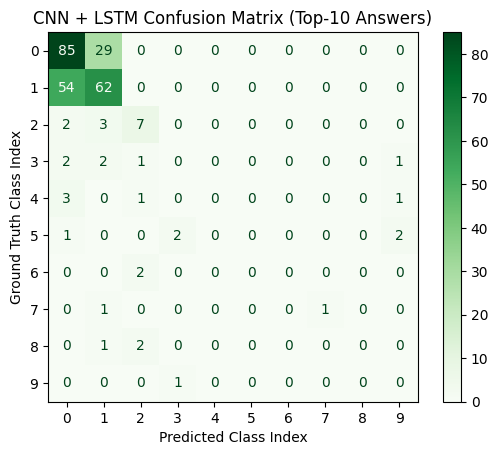

,Accuracy
no,0.745614
yes,0.534483
axial,0.583333
right,0.000000
left,0.000000
pa,0.000000
brain,0.000000
ct,0.500000
fat,0.000000
x-ray,0.000000


In [ ]:
all_preds_cnn = []
all_labels_cnn = []

model_cnn.eval()
with torch.no_grad():
    for images, questions, labels in val_loader_cnn:
        images = images.to(device)
        questions = questions.to(device)

        outputs = model_cnn(images, questions)
        preds = outputs.argmax(dim=1)

        all_preds_cnn.extend(preds.cpu().numpy())
        all_labels_cnn.extend(labels.cpu().numpy())

top_answers_cnn = (
    pd.Series(df_cnn['ANSWER'])
    .value_counts()
    .head(10)
    .index
    .tolist()
)

ans2idx_top = {ans: idx for idx, ans in enumerate(top_answers_cnn)}

filtered_preds = []
filtered_labels = []

for p, l in zip(all_preds_cnn, all_labels_cnn):
    pred_ans = idx2answer[p]
    true_ans = idx2answer[l]

    # Only keep samples whose GT is in Top-10
    if true_ans in ans2idx_top:
        filtered_labels.append(ans2idx_top[true_ans])
        filtered_preds.append(ans2idx_top.get(pred_ans, -1))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_cnn = confusion_matrix(
    filtered_labels,
    filtered_preds,
    labels=list(range(len(top_answers_cnn)))
)

disp_cnn = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=list(range(len(top_answers_cnn)))
)

disp_cnn.plot(cmap=plt.cm.Greens)
plt.title("CNN + LSTM Confusion Matrix (Top-10 Answers)")
plt.xlabel("Predicted Class Index")
plt.ylabel("Ground Truth Class Index")
plt.show()

per_class_acc_cnn = {}

for ans, idx in ans2idx_top.items():
    indices = [i for i, l in enumerate(filtered_labels) if l == idx]
    correct = sum(filtered_preds[i] == idx for i in indices)
    total = len(indices)

    per_class_acc_cnn[ans] = correct / total if total > 0 else 0

acc_df_cnn = pd.DataFrame.from_dict(
    per_class_acc_cnn,
    orient='index',
    columns=['Accuracy']
)

display(acc_df_cnn)

# **3.0 BLIP Advanced Model**

### 3.1 Dataset & Dataloader

In [ ]:
df_blip = pd.read_excel(EXCEL_PATH)
df_blip['image_name'] = df_blip['IMAGEID'].apply(lambda x: os.path.basename(str(x)))
df_blip['image_path'] = df_blip['image_name'].apply(lambda x: os.path.join(IMAGE_DIR, x))
df_blip = df_blip[['image_path','QUESTION','ANSWER']]
df_blip = df_blip[df_blip['image_path'].apply(os.path.exists)].reset_index(drop=True)
df_blip['ANSWER'] = df_blip['ANSWER'].str.lower().str.strip()

print("BLIP Total samples:", len(df_blip))

BLIP Total samples: 2248


In [ ]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")

class BLIPVQADataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert("RGB")
        question = row['QUESTION']
        answer = row['ANSWER']
        return image, question, answer

def collate_fn(batch):
    images, questions, answers = zip(*batch)
    answers = [str(a) if a is not None else "" for a in answers]
    inputs = processor(images=list(images), text=list(questions),
                       padding=True, truncation=True, return_tensors="pt")
    labels = processor.tokenizer(answers, padding=True, truncation=True, return_tensors="pt").input_ids
    inputs["labels"] = labels
    return inputs

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

### 3.2 Train/Validation Split

In [ ]:
train_df_blip, val_df_blip = train_test_split(df_blip, test_size=0.2, random_state=42)

train_dataset_blip = BLIPVQADataset(train_df_blip)
val_dataset_blip   = BLIPVQADataset(val_df_blip)

train_loader_blip = torch.utils.data.DataLoader(train_dataset_blip, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader_blip   = torch.utils.data.DataLoader(val_dataset_blip, batch_size=4, shuffle=False, collate_fn=collate_fn)

split_df_blip = pd.DataFrame({
    "Model": ["BLIP"],
    "Train Samples": [len(train_dataset_blip)],
    "Validation Samples": [len(val_dataset_blip)]
})
display(split_df_blip)

,Model,Train Samples,Validation Samples
0,BLIP,1798,450


### 3.3 Model Initialization

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_blip = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

# Freeze vision model to save memory & speed
for param in model_blip.vision_model.parameters():
    param.requires_grad = False

optimizer_blip = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_blip.parameters()), lr=5e-5)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

### 3.4 Training Loop

In [ ]:
num_epochs = 5
train_losses_blip = []

for epoch in range(num_epochs):
    model_blip.train()
    total_loss = 0

    for batch in train_loader_blip:
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model_blip(**batch)
        loss = outputs.loss
        optimizer_blip.zero_grad()
        loss.backward()
        optimizer_blip.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_blip)
    train_losses_blip.append(avg_loss)
    print(f"BLIP Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_loss:.4f}")

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


BLIP Epoch 1/5 | Train Loss: 2.4306
BLIP Epoch 2/5 | Train Loss: 0.9629
BLIP Epoch 3/5 | Train Loss: 0.7122
BLIP Epoch 4/5 | Train Loss: 0.5073
BLIP Epoch 5/5 | Train Loss: 0.3615


### 3.5 Validation Loop

In [ ]:
model_blip.eval()

val_losses_blip = []
total_correct = 0
all_preds_blip = []
all_labels_blip = []

with torch.no_grad():
    for batch in val_loader_blip:
        batch_inputs = {k: v.to(device) for k, v in batch.items()}

        outputs = model_blip(**batch_inputs)
        val_losses_blip.append(outputs.loss.item())

        gen_ids = model_blip.generate(
            pixel_values=batch_inputs['pixel_values'],
            input_ids=batch_inputs['input_ids'],
            attention_mask=batch_inputs['attention_mask'],
            max_length=20,
            num_beams=3
        )

        preds = [
            processor.decode(g, skip_special_tokens=True).lower().strip()
            for g in gen_ids
        ]

        gts = [
            processor.decode(l, skip_special_tokens=True).lower().strip()
            for l in batch_inputs['labels']
        ]

        all_preds_blip.extend(preds)
        all_labels_blip.extend(gts)

        total_correct += sum(p == gt for p, gt in zip(preds, gts))

val_acc_blip = total_correct / len(val_dataset_blip)
print(f"BLIP Validation Accuracy (Exact Match): {val_acc_blip:.4f}")

BLIP Validation Accuracy (Exact Match): 0.4622


### 3.6 Plot loss

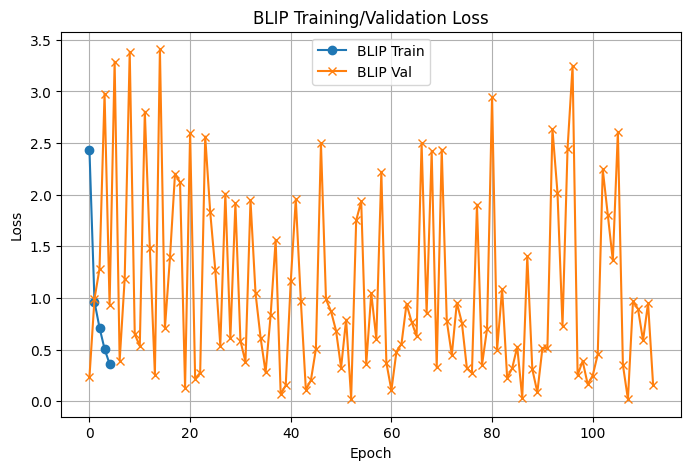

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_blip, marker='o', label='BLIP Train')
plt.plot(val_losses_blip, marker='x', label='BLIP Val')
plt.title("BLIP Training/Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 3.7 Sample inference table

In [ ]:
sample_blip = val_df_blip.sample(10, random_state=42)
results_blip = []

model_blip.eval()
with torch.no_grad():
    for _, row in sample_blip.iterrows():
        img = Image.open(row['image_path']).convert("RGB")
        question = row['QUESTION']
        gt = row['ANSWER'].lower().strip()

        inputs = processor(images=img, text=question, return_tensors="pt").to(device)
        gen_ids = model_blip.generate(**inputs, max_length=20, num_beams=5)

        pred = processor.decode(gen_ids[0], skip_special_tokens=True).lower().strip()

        match = pred == gt

        if match:
            comment = "Correct"
        elif pred in ["unknown", "i don't know", "cannot determine"]:
            comment = "Unknown / Open-ended"
        else:
            comment = "Mismatch / Hallucination"

        results_blip.append({
            "Question": question,
            "Ground Truth": gt,
            "BLIP Prediction": pred,
            "Match?": match,
            "Comment": comment
        })

blip_inference_df = pd.DataFrame(results_blip)
display(blip_inference_df)

,Question,Ground Truth,BLIP Prediction,Match?,Comment
0,Where is the abnormal mass located with respec...,right upper lobe,right side,False,Mismatch / Hallucination
1,The patient's left contains a bright round org...,left kidney,pancreas,False,Mismatch / Hallucination
2,is the stomach filled?,yes,yes,True,Correct
3,Are the kidneys visible in this image?,yes,yes,True,Correct
4,is there evidence of brainstem herniation in t...,no,no,True,Correct
5,is there contrast material showing air-fluid l...,yes,yes,True,Correct
6,Where is the mass?,left rectus abdominus,cerebellum,False,Mismatch / Hallucination
7,Which lung has more extensive infiltration?,left,right lung lung,False,Mismatch / Hallucination
8,what is the composition of the mass?,fat,fat stranding to the right side as well as pa,False,Mismatch / Hallucination
9,Describe the size and density of this lesion?,"5.6cm focal, predominantly hypodense","5cmcmcm focal, predominantly hypodense",False,Mismatch / Hallucination


### 3.8 Confusion Matrix

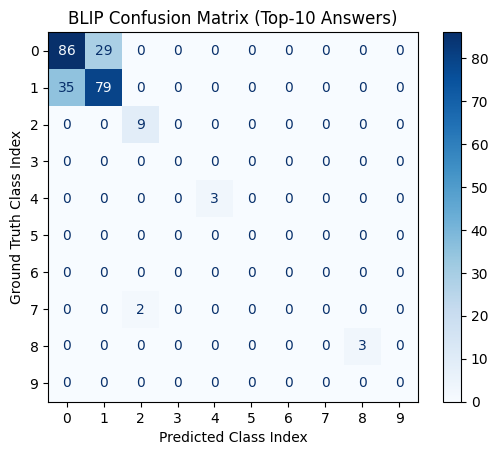

,Accuracy
yes,0.741379
no,0.692982
axial,0.750000
right,0.000000
pa,0.600000
left,0.000000
right frontal lobe,0.000000
mri,0.000000
right sided pleural effusion,1.000000
enlarged,0.000000


In [ ]:
all_preds_blip = []
all_labels_blip = []

model_blip.eval()
with torch.no_grad():
    for batch in val_loader_blip:
        batch_inputs = {k: v.to(device) for k, v in batch.items()}

        gen_ids = model_blip.generate(
            pixel_values=batch_inputs['pixel_values'],
            input_ids=batch_inputs['input_ids'],
            attention_mask=batch_inputs['attention_mask'],
            max_length=20,
            num_beams=3
        )

        preds = [
            processor.decode(g, skip_special_tokens=True).lower().strip()
            for g in gen_ids
        ]

        gts = [
            processor.decode(l, skip_special_tokens=True).lower().strip()
            for l in batch_inputs['labels']
        ]

        all_preds_blip.extend(preds)
        all_labels_blip.extend(gts)

top_answers_blip = (
    pd.Series(all_labels_blip)
    .value_counts()
    .head(10)
    .index
    .tolist()
)

ans2idx_blip = {ans: idx for idx, ans in enumerate(top_answers_blip)}

filtered_preds_blip = []
filtered_labels_blip = []

for p, l in zip(all_preds_blip, all_labels_blip):
    if l in ans2idx_blip:            # keep only Top-10 GT
        filtered_labels_blip.append(ans2idx_blip[l])
        filtered_preds_blip.append(ans2idx_blip.get(p, -1))  # out-of-top → -1
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_blip = confusion_matrix(
    filtered_labels_blip,
    filtered_preds_blip,
    labels=list(range(len(top_answers_blip)))
)

disp_blip = ConfusionMatrixDisplay(
    confusion_matrix=cm_blip,
    display_labels=list(range(len(top_answers_blip)))
)

disp_blip.plot(cmap=plt.cm.Blues)
plt.title("BLIP Confusion Matrix (Top-10 Answers)")
plt.xlabel("Predicted Class Index")
plt.ylabel("Ground Truth Class Index")
plt.show()

per_class_acc_blip = {}

for ans, idx in ans2idx_blip.items():
    indices = [i for i, l in enumerate(filtered_labels_blip) if l == idx]
    correct = sum(filtered_preds_blip[i] == idx for i in indices)
    total = len(indices)

    per_class_acc_blip[ans] = correct / total if total > 0 else 0

acc_df_blip = pd.DataFrame.from_dict(
    per_class_acc_blip,
    orient='index',
    columns=['Accuracy']
)

display(acc_df_blip)

# **4.0 Results & Comparison**

### 4.1 Plot Training and Validation Loss Analysis

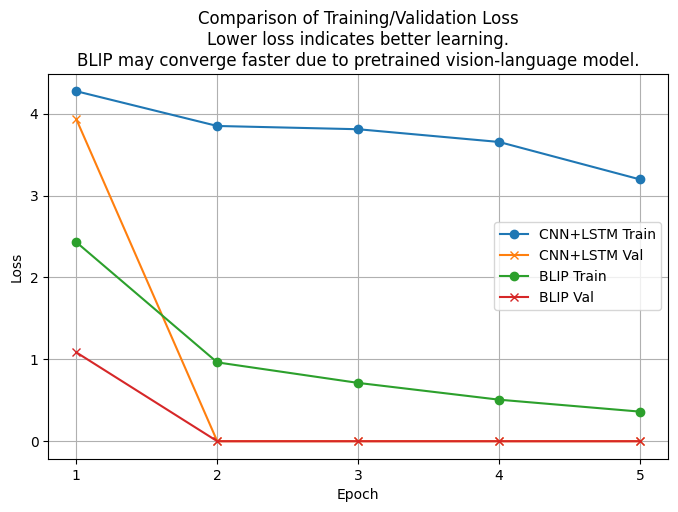

📊 Training & Validation Loss per Epoch


,Epoch,CNN+LSTM Train Loss,CNN+LSTM Val Loss,BLIP Train Loss,BLIP Val Loss
0,1,4.274527,3.932722,2.430571,1.085036
1,2,3.850084,0.000000,0.962935,0.000000
2,3,3.810254,0.000000,0.712180,0.000000
3,4,3.654883,0.000000,0.507289,0.000000
4,5,3.197451,0.000000,0.361500,0.000000


In [ ]:
def average_val_loss_per_epoch(val_losses, val_loader, num_epochs):
    avg_val_losses = []
    batch_per_epoch = len(val_loader)
    for i in range(num_epochs):
        start = i * batch_per_epoch
        end = (i+1) * batch_per_epoch
        epoch_loss = sum(val_losses[start:end]) / batch_per_epoch
        avg_val_losses.append(epoch_loss)
    return avg_val_losses

val_losses_cnn_epoch  = average_val_loss_per_epoch(val_losses_cnn, val_loader_cnn, num_epochs)
val_losses_blip_epoch = average_val_loss_per_epoch(val_losses_blip, val_loader_blip, num_epochs)

# Plot Training & Validation Loss
plt.figure(figsize=(8,5))
plt.plot(train_losses_cnn, marker='o', label='CNN+LSTM Train')
plt.plot(val_losses_cnn_epoch, marker='x', label='CNN+LSTM Val')
plt.plot(train_losses_blip, marker='o', label='BLIP Train')
plt.plot(val_losses_blip_epoch, marker='x', label='BLIP Val')
plt.title("Comparison of Training/Validation Loss\nLower loss indicates better learning.\nBLIP may converge faster due to pretrained vision-language model.")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(num_epochs), range(1, num_epochs+1))
plt.legend()
plt.grid(True)
plt.show()

loss_table = pd.DataFrame({
    "Epoch": list(range(1, num_epochs+1)),
    "CNN+LSTM Train Loss": train_losses_cnn,
    "CNN+LSTM Val Loss": val_losses_cnn_epoch,
    "BLIP Train Loss": train_losses_blip,
    "BLIP Val Loss": val_losses_blip_epoch
})

print("📊 Training & Validation Loss per Epoch")
display(loss_table)

### 4.2 Quantitative Performance Comparison

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["CNN+LSTM", "BLIP"],
    "Validation Accuracy (%)": [
        round(val_acc_cnn * 100, 2),
        round(val_acc_blip * 100, 2)
    ],
    "Final Train Loss": [
        round(train_losses_cnn[-1], 4),
        round(train_losses_blip[-1], 4)
    ],
    "Final Validation Loss": [
        round(val_losses_cnn[-1], 4),
        round(val_losses_blip[-1], 4)
    ]
})

display(comparison_df)

,Model,Validation Accuracy (%),Final Train Loss,Final Validation Loss
0,CNN+LSTM,34.44,3.1975,1.5866
1,BLIP,46.22,0.3615,0.1600


### 4.3 Qualitative Analysis of Sample Predictions

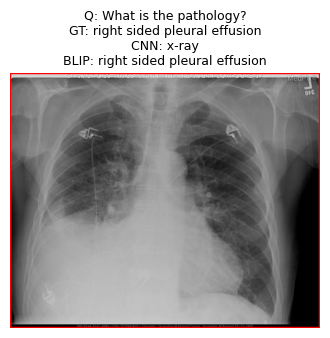

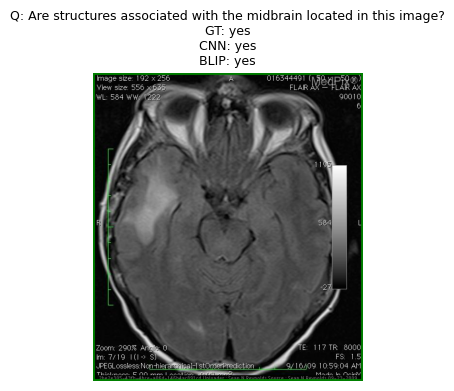

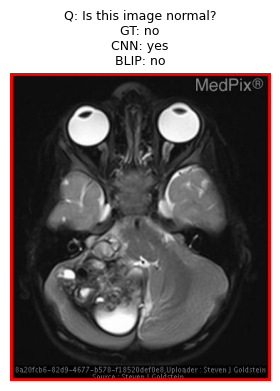

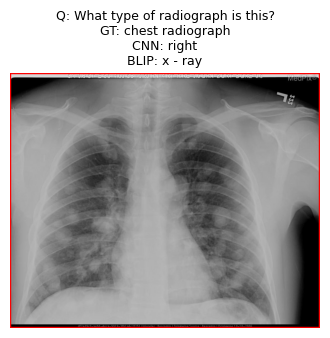

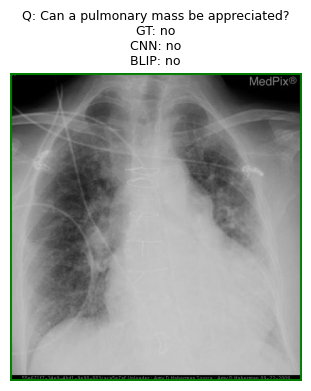

In [ ]:
from PIL import ImageDraw

sample_cmp = val_df_cnn.sample(5, random_state=15)
for _, row in sample_cmp.iterrows():
    img_path = row['image_path']
    # CNN prediction
    img_tensor = transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
    q_tensor = torch.tensor([row['question_encoded']], dtype=torch.long).to(device)
    out_cnn = model_cnn(img_tensor, q_tensor).argmax(dim=1).item()
    pred_cnn = idx2answer[out_cnn]

    # BLIP prediction
    img = Image.open(img_path).convert("RGB")
    inputs = processor(images=img, text=row['QUESTION'], return_tensors="pt").to(device)
    with torch.no_grad():
        gen_ids = model_blip.generate(**inputs, max_length=20, num_beams=5)
    pred_blip = processor.decode(gen_ids[0], skip_special_tokens=True)

    gt = row['ANSWER']
    match_cnn = pred_cnn == gt
    match_blip = pred_blip.lower().strip() == gt.lower().strip()

    draw = ImageDraw.Draw(img)
    color = 'green' if match_cnn and match_blip else 'red'
    draw.rectangle([0,0,img.width-1,img.height-1], outline=color, width=4)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Q: {row['QUESTION']}\nGT: {gt}\nCNN: {pred_cnn}\nBLIP: {pred_blip}", fontsize=9)
    plt.show()

### 4.4 Evaluation: Precision, Recall, F1 & Closed/Open Accuracy

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# ----------- CNN+LSTM -----------

all_preds_cnn_np = np.array(all_preds_cnn)
all_labels_cnn_np = np.array(all_labels_cnn)

precision_cnn = precision_score(all_labels_cnn_np, all_preds_cnn_np, average='macro', zero_division=0)
recall_cnn = recall_score(all_labels_cnn_np, all_preds_cnn_np, average='macro', zero_division=0)
f1_cnn = f1_score(all_labels_cnn_np, all_preds_cnn_np, average='macro', zero_division=0)

close_answers = ["yes", "no", "normal", "abnormal"]
val_df_cnn['is_close'] = val_df_cnn['ANSWER'].apply(
    lambda x: str(x).lower().strip() in close_answers if pd.notna(x) else False
)

close_correct = 0
close_total = 0
open_correct = 0
open_total = 0

for pred, gt, is_close in zip(all_preds_cnn, val_df_cnn['ANSWER'], val_df_cnn['is_close']):
    pred_str = str(idx2answer[pred]).lower().strip() # convert index to answer
    gt_str = str(gt).lower().strip()
    if is_close:
        close_total += 1
        if pred_str == gt_str:
            close_correct += 1
    else:
        open_total += 1
        if pred_str == gt_str:
            open_correct += 1

close_acc_cnn = close_correct / close_total if close_total > 0 else 0
open_acc_cnn = open_correct / open_total if open_total > 0 else 0

# ----------- BLIP -----------

filtered_preds_blip_np = np.array(filtered_preds_blip)
filtered_labels_blip_np = np.array(filtered_labels_blip)

precision_blip = precision_score(filtered_labels_blip_np, filtered_preds_blip_np, average='macro', zero_division=0)
recall_blip = recall_score(filtered_labels_blip_np, filtered_preds_blip_np, average='macro', zero_division=0)
f1_blip = f1_score(filtered_labels_blip_np, filtered_preds_blip_np, average='macro', zero_division=0)

val_df_blip['is_close'] = val_df_blip['ANSWER'].apply(
    lambda x: str(x).lower().strip() in close_answers if pd.notna(x) else False
)

close_correct = 0
close_total = 0
open_correct = 0
open_total = 0

for pred, gt, is_close in zip(all_preds_blip, val_df_blip['ANSWER'], val_df_blip['is_close']):
    pred_str = str(pred).lower().strip()
    gt_str = str(gt).lower().strip()
    if is_close:
        close_total += 1
        if pred_str == gt_str:
            close_correct += 1
    else:
        open_total += 1
        if pred_str == gt_str:
            open_correct += 1

close_acc_blip = close_correct / close_total if close_total > 0 else 0
open_acc_blip = open_correct / open_total if open_total > 0 else 0

# ----------- Summary Table -----------

metrics_df = pd.DataFrame({
    "Model": ["CNN+LSTM", "BLIP"],
    "Precision": [precision_cnn, precision_blip],
    "Recall": [recall_cnn, recall_blip],
    "F1-score": [f1_cnn, f1_blip]
})

oc_df = pd.DataFrame({
    "Model": ["CNN+LSTM", "BLIP"],
    "Closed-ended Accuracy": [close_acc_cnn, close_acc_blip],
    "Open-ended Accuracy": [open_acc_cnn, open_acc_blip]
})

print("📊 Metrics:")
display(metrics_df)

print("\n\n📊 Open/Closed-ended Accuracy:")
display(oc_df)

📊 Metrics:


,Model,Precision,Recall,F1-score
0,CNN+LSTM,0.007397,0.014152,0.009114
1,BLIP,0.387310,0.344033,0.360914




✅ Open/Closed-ended Accuracy:


,Model,Closed-ended Accuracy,Open-ended Accuracy
0,CNN+LSTM,0.636364,0.036530
1,BLIP,0.714286,0.191781


### 4.4 Summary of Model Comparison

In [ ]:
if val_acc_blip > val_acc_cnn:
    best_model = "BLIP"
    reason = "BLIP outperforms CNN+LSTM in validation accuracy and leverages pretrained vision-language model for better generalization."
else:
    best_model = "CNN+LSTM"
    reason = "CNN+LSTM performs better or equal, likely due to better alignment with dataset-specific features."

print(f"Better model based on validation accuracy: {best_model}")
print(f"Reason: {reason}")

Better model based on validation accuracy: BLIP
Reason: BLIP outperforms CNN+LSTM in validation accuracy and leverages pretrained vision-language model for better generalization.
